# Homework 2: Machine Learning for Regression


In [333]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [334]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [335]:
select_columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df = df[select_columns].copy()

## EDA

Does `fuel_efficiency_mpg` have a long tail?

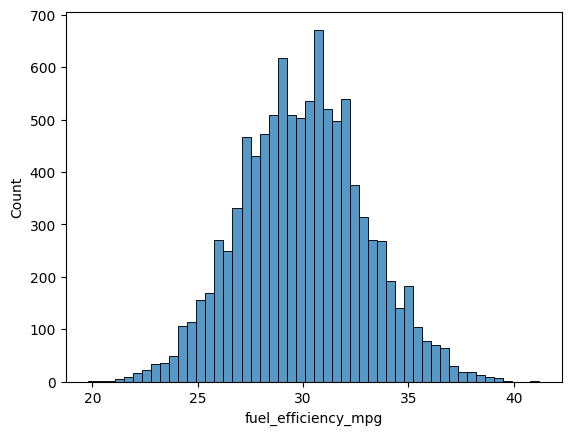

mean:     30.0
median:   30.0
skewness: 0.08


In [336]:
sns.histplot(
    data=df,
    bins=50,
    x='fuel_efficiency_mpg'
)

plt.show()

target = df['fuel_efficiency_mpg']
print('mean:    ', round(target.mean(), 2))
print('median:  ', round(target.median(), 2))
print('skewness:', round(target.skew(), 2))

The distribution is roughly symmetric: mean and median are both close to 30 and the skewness is close to 0. There is no long tail, so the target is used as is (no log transformation).

## Question 1. Missing values

In [337]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Question 2. Median of horsepower

In [338]:
print(df['horsepower'].median())

254.0


## Helper functions


In [339]:
def split_data(df, seed):
    """Shuffle and split 60/20/20, exactly as in the lecture."""
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test


def get_xy(df, target='fuel_efficiency_mpg'):
    """Separate the features (X) from the target (y)."""
    return df.drop(columns=[target]), df[target].values


def train_linear_regression(X, y, r=0.0):
    """Return the bias w0 and the weights w."""
    X_ext = np.column_stack([np.ones(X.shape[0]), X])

    XTX = X_ext.T.dot(X_ext)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X_ext.T).dot(y)

    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))


def train_and_predict(X_train, y_train, X_eval, fill_value=0, r=0.0):
    """Fill the missing values, train on X_train and predict X_eval."""
    w0, w = train_linear_regression(X_train.fillna(fill_value).values, y_train, r=r)
    return w0 + X_eval.fillna(fill_value).values.dot(w)

## Split the data (seed 42)

In [340]:
df_train, df_val, df_test = split_data(df, seed=42)

X_train, y_train = get_xy(df_train)
X_val, y_val = get_xy(df_val)

len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

## Question 3. Fill missing values with 0 or with the mean

The mean is computed on the training set only, and the same value is used to fill the validation set.

In [341]:
mean_hp = X_train['horsepower'].mean()   # training set only

pred_zero = train_and_predict(X_train, y_train, X_val, fill_value=0)
pred_mean = train_and_predict(X_train, y_train, X_val, fill_value=mean_hp)

print('RMSE filling with 0:   ', round(rmse(y_val, pred_zero), 3))
print('RMSE filling with mean:', round(rmse(y_val, pred_mean), 3))

RMSE filling with 0:    2.205
RMSE filling with mean: 2.202


## Question 4. Regularization

Missing values filled with 0. RMSE rounded to 4 decimal digits; in case of a tie, the smallest `r` wins.

In [342]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    pred = train_and_predict(X_train, y_train, X_val, fill_value=0, r=r)
    print(f'r = {r:<5}  RMSE = {rmse(y_val, pred):.4f}')

r = 0      RMSE = 2.2053
r = 0.01   RMSE = 2.2058
r = 0.1    RMSE = 2.2241
r = 1      RMSE = 2.3492
r = 5      RMSE = 2.4094
r = 10     RMSE = 2.4195
r = 100    RMSE = 2.4292


## Question 5. Effect of the seed



In [343]:
scores = []

for seed in range(10):
    df_train_s, df_val_s, _ = split_data(df, seed=seed)
    X_train_s, y_train_s = get_xy(df_train_s)
    X_val_s, y_val_s = get_xy(df_val_s)

    pred = train_and_predict(X_train_s, y_train_s, X_val_s, fill_value=0, r=0)
    scores.append({'seed': seed, 'rmse': rmse(y_val_s, pred)})

df_scores = pd.DataFrame(scores)
print('std:', round(np.std(df_scores['rmse'].values), 3))

std: 0.029


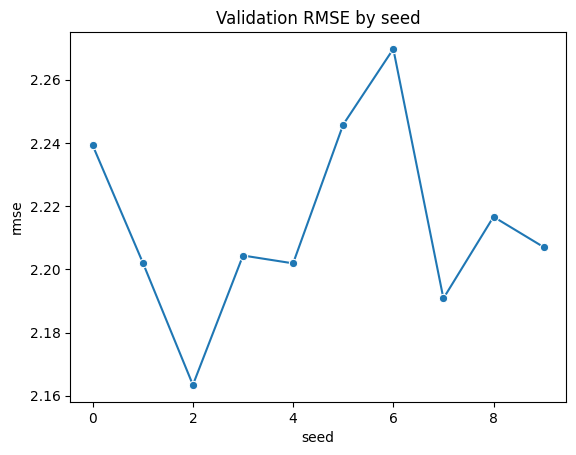

In [344]:
sns.lineplot(data=df_scores, x='seed', y='rmse', marker='o')
plt.title('Validation RMSE by seed')
plt.show()

## Question 6. Final model on the test set


In [345]:
df_train, df_val, df_test = split_data(df, seed=9)
df_full_train = pd.concat([df_train, df_val])

X_full_train, y_full_train = get_xy(df_full_train)
X_test, y_test = get_xy(df_test)

pred = train_and_predict(X_full_train, y_full_train, X_test, fill_value=0, r=0.001)
print('Test RMSE:', round(rmse(y_test, pred), 3))

Test RMSE: 2.236
